# Stat153/248 Lecture 12 - Power spectral analysis 

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import math
plt.rcParams['figure.figsize'] = (4, 3)

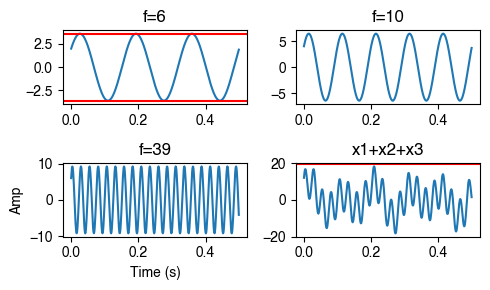

In [3]:
fs = 1000 # sampling rate
t = np.arange(0, 0.5, 1/fs)

# Let's make three different sinusoids:
f = [6,10,39] # Frequencies of the sinusoids
x1 = 2*np.cos(2*math.pi*f[0]*t) + 3*np.sin(2*math.pi*f[0]*t)
x2 = 4*np.cos(2*math.pi*f[1]*t) + 5*np.sin(2*math.pi*f[1]*t)
x3 = 6*np.cos(2*math.pi*f[2]*t) +7*np.sin(2*math.pi*f[2]*t)

plt.figure(figsize=(5,3))
plt.subplot(2,2,1)
plt.plot(t,x1)
plt.axhline(-np.sqrt(2**2+3**2),color='r')
plt.axhline(np.sqrt(2**2+3**2),color='r')
plt.title(f'f={f[0]}')
plt.subplot(2,2,2)
plt.plot(t,x2)
plt.title(f'f={f[1]}')
plt.subplot(2,2,3)
plt.plot(t,x3)
plt.title(f'f={f[2]}')
plt.xlabel('Time (s)')
plt.ylabel('Amp')
plt.subplot(2,2,4)
plt.plot(t,x1+x2+x3)
plt.axhline(np.sqrt(2**2+3**2)+np.sqrt(4**2+5**2)+np.sqrt(6**2+7**2), color='r')
plt.title('x1+x2+x3')
plt.tight_layout()

Note that the amplitudes of each of these series are defined by $\sqrt{U_1^2+U_2^2}$. For the sum of sinusoids, it's theoretical maximum amplitude is given by the sum of the amplitudes of each of the components, but this maximum will only be reached if the peaks of the sinusoids are in phase (which does not always happen if they aren't harmonically related - meaning they aren't integer multiples of some underlying frequency). 

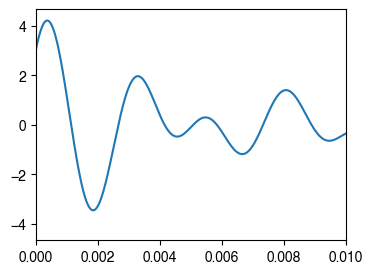

In [4]:
from IPython.display import Audio, display

fs2 = 44100 # sampling rate
t2 = np.arange(0, 1, 1/fs2)

# Let's make three different sinusoids:
freqs = [261.6, 329.7, 392] # Frequencies of the sinusoids 
#freqs = [200, 400, 800]

tone = np.zeros(len(t2),)
for f in freqs:
    tone+= 1*np.cos(2*math.pi*f*t2) + 1*np.sin(2*math.pi*f*t2)
#
#tone+= 10*np.cos(2*math.pi*f*t2) + 10*np.sin(2*math.pi*f*t2)

plt.plot(t2,tone)
plt.gca().set_xlim([0,0.01])
display(Audio(tone, rate=fs2, autoplay=False))

Text(0, 0.5, 'power')

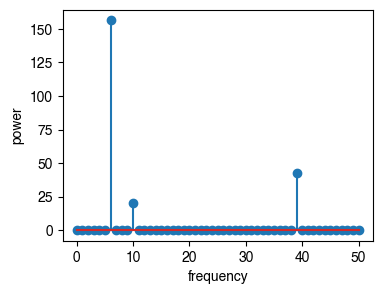

In [5]:
from scipy.signal import periodogram

fs = 100 # sampling rate
t = np.arange(0, 1, 1/fs)

# Let's make three different sinusoids:
f = [6,10,39] # Frequencies of the sinusoids
x1 = 12*np.cos(2*math.pi*f[0]*t) + 13*np.sin(2*math.pi*f[0]*t)
x2 = 4*np.cos(2*math.pi*f[1]*t) + 5*np.sin(2*math.pi*f[1]*t)
x3 = 6*np.cos(2*math.pi*f[2]*t) +7*np.sin(2*math.pi*f[2]*t)

freqs, power = periodogram(x1+x2+x3, fs=fs)

plt.stem(freqs, power)
plt.xlabel('frequency')
plt.ylabel('power')

In [6]:
freqs

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.])

(0.0, 600.0)

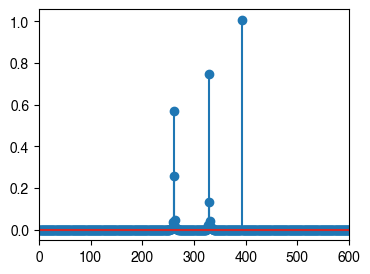

In [7]:
freqs, power = periodogram(tone, fs=fs2)

plt.stem(freqs, power)
plt.gca().set_xlim([0,600])

In the periodogram, our frequency resolution is $1/T$ where $T$ is the duration of our signal (in seconds! not samples!). 

In [8]:
import astsa

In [9]:
sunspots=astsa.load_sunspotz()

0      1749.0
1      1749.5
2      1750.0
3      1750.5
4      1751.0
        ...  
454    1976.0
455    1976.5
456    1977.0
457    1977.5
458    1978.0
Name: Time, Length: 459, dtype: float64


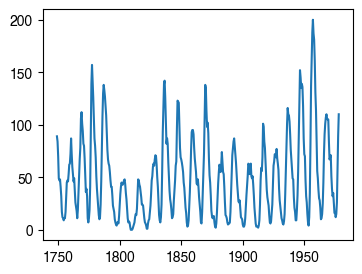

In [10]:
plt.plot(sunspots['Time'], sunspots['Value'])
print(sunspots['Time'])

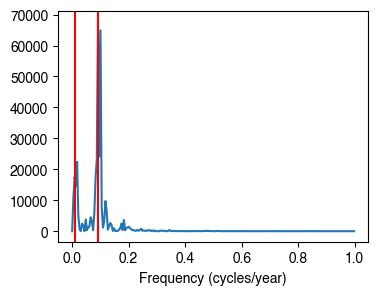

In [14]:
freqs, power = periodogram(sunspots['Value'], fs=2)
plt.plot(freqs,power)
plt.xlabel('Frequency (cycles/year)')
plt.axvline(1/11, color='r') # 1 cycle every 11 years
plt.axvline(1/110, color='r') # 1 cycle every 80-110 years (Gleissberg cycle), slow!

/var/folders/3f/h3pnh73d18ldksmkrp_fvtk00000gn/T/ipykernel_23869/2295188987.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.semilogx(1/freqs,power)


Text(0.5, 0, 'Period')

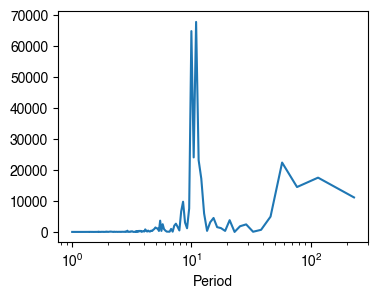

In [16]:
plt.semilogx(1/freqs,power)
plt.xlabel('Period')

/var/folders/3f/h3pnh73d18ldksmkrp_fvtk00000gn/T/ipykernel_23869/295426981.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  [fs3, w] =scipy.io.wavfile.read('sounds/lec1_aah_hi.wav')


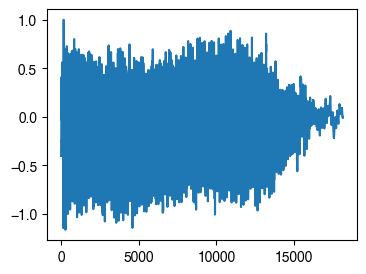

In [21]:
import scipy.io.wavfile

[fs3, w] =scipy.io.wavfile.read('sounds/lec1_aah_hi.wav')
w = w/w.max()
plt.plot(w)

t = np.arange(0, len(w)/fs3, 1/fs3)
line_noise = 1*np.cos(2*math.pi*60*t) + 1*np.sin(2*math.pi*60*t)

display(Audio(w+10*line_noise, rate=fs3, autoplay=False))

(0.0, 600.0)

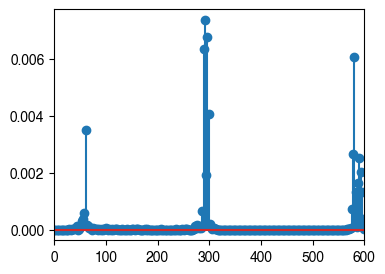

In [27]:
freqs, power = periodogram(w+0.1*line_noise, fs=fs3)

plt.stem(freqs, power)
plt.gca().set_xlim([0,600])

In [28]:
periodogram?

Signature:
periodogram(
    x,
    fs=1.0,
    window='boxcar',
    nfft=None,
    detrend='constant',
    return_onesided=True,
    scaling='density',
    axis=-1,
)
Docstring:
Estimate power spectral density using a periodogram.

Parameters
----------
x : array_like
    Time series of measurement values
fs : float, optional
    Sampling frequency of the `x` time series. Defaults to 1.0.
window : str or tuple or array_like, optional
    Desired window to use. If `window` is a string or tuple, it is
    passed to `get_window` to generate the window values, which are
    DFT-even by default. See `get_window` for a list of windows and
    required parameters. If `window` is array_like it will be used
    directly as the window and its length must be equal to the length
    of the axis over which the periodogram is computed. Defaults
    to 'boxcar'.
nfft : int, optional
    Length of the FFT used. If `None` the length of `x` will be
    used.
detrend : str or function or `False`, optiona